### trying to replicate the ViT paper (vision transformer)
link:https://arxiv.org/abs/2010.11929

In [34]:
import torch
import torchvision

In [35]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [36]:
from pathlib import Path
image_path=Path("data/pizza_steak_sushi")
image_path

WindowsPath('data/pizza_steak_sushi')

In [37]:
train_dir=image_path/"train"
test_dir=image_path/"test"
train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

In [38]:
!nvidia-smi

Sun Jul 13 16:45:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   49C    P5             10W /   75W |     908MiB /   6144MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [39]:
from going_modular import data_setup
from torchvision import transforms
IMG_SIZE=224

manual_transforms=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor()
])

print(f"manually created transform: {manual_transforms}")

manually created transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [40]:
#making smallest version of the ViT
BATCH_SIZE=32

train_dataloader,test_dataloader,class_names=data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=BATCH_SIZE,
)
len(train_dataloader),len(test_dataloader),class_names

(8, 3, ['pizza', 'steak', 'sushi'])

In [41]:
#visualize a single image
image_batch,label_batch=next(iter(train_dataloader))

image,label=image_batch[0],label_batch[0]

image.shape,label

(torch.Size([3, 224, 224]), tensor(1))

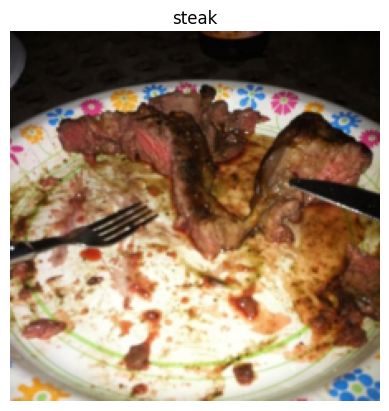

In [42]:
import matplotlib.pyplot as plt

plt.imshow(image.permute(1,2,0))#because matplot requires(h,w,c)
plt.title(class_names[label])
plt.axis(False);

In [43]:
#replicating the vit
#inputs:what goes into the model
#outputs:what comes out of the model/layer/blocks
#layers:takes an input,manipulates it with a function(eg.self-attention)
#block:stacks of the layers

#### The flowchart of the model

![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-figure-1-architecture-overview.png?raw=true)

#### Four equation

![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-four-equations.png?raw=true)

An overview of the model is depicted in Figure 1. The standard Transformer receives as input a 1D sequence of token embeddings. To handle 2D images, we reshape the image $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$ into a sequence of flattened 2D patches $\mathbf{x}_p \in \mathbb{R}^{N \times\left(P^2 \cdot C\right)}$, where $(H, W)$ is the resolution of the original image, $C$ is the number of channels, $(P, P)$ is the resolution of each image patch, and $N=H W / P^2$ is the resulting number of patches, which also serves as the effective input sequence length for the Transformer. The Transformer uses constant latent vector size $D$ through all of its layers, so we flatten the patches and map to $D$ dimensions with a trainable linear projection (Eq. 1). We refer to the output of this projection as the patch embeddings.

Similar to BERT's [class] token, we prepend a learnable embedding to the sequence of embedded patches $\left(\mathbf{z}_0^0=\mathbf{x}_{\text {class }}\right)$, whose state at the output of the Transformer encoder $\left(\mathbf{z}_L^0\right)$ serves as the image representation $\mathbf{y}$ (Eq. 4). Both during pre-training and fine-tuning, a classification head is attached to $\mathbf{z}_L^0$. The classification head is implemented by a MLP with one hidden layer at pre-training time and by a single linear layer at fine-tuning time.

Position embeddings are added to the patch embeddings to retain positional information. We use standard learnable 1D position embeddings, since we have not observed significant performance gains from using more advanced 2D-aware position embeddings (Appendix D.4). The resulting sequence of embedding vectors serves as input to the encoder.
The Transformer encoder (Vaswani et al., 2017) consists of alternating layers of multiheaded selfattention (MSA, see Appendix A) and MLP blocks (Eq. 2, 3). Layernorm (LN) is applied before every block, and residual connections after every block (Wang et al., 2019; Baevski \& Auli, 2019).

pseudo_code:
```python
#eq1
x_input=[class_token,image_patch_1,image_patch_2,.....,image_patch_N]+
        [class_token_pos,image_patch_1_pos,image_path_2_pos,......image_patch_N_pos]


#eq2
x_output_msa_block=msa_layer(ln_layer(x_input))+x_input

#eq3
x_output_mlp_block=mlp_layer(ln_layer(x_output_msa_block))+x_output_msa_block

#eq4
y = linear_layer(ln_layer(x_output_mlp_block))
```
#### Table
![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-table-1.png?raw=true)

* vit-base,vit-large and vit-huge are all different sizes of the same model architecture.
* layers:no of transformer encoder layers.
* hidden size $D$ - the embedding the size throuhgout the architecture.(eg-768 flatten layer dimmension)
* mlp size- the number of hidden units / neurons in the mlp
* head- the number of multi-head self-attention.